# 🚦 Akıllı Şehir & Ulaşım: METR-LA Trafik Veri Seti Analizi

**Veri Kaynağı:** METR-LA (Los Angeles Metropolitan Traffic Dataset)  
**İçerik:** 207 sensörden 4 aylık (Mart–Haziran 2012), 5 dakikalık periyotlarla kaydedilmiş araç hız verileri (km/s)  
**Tema:** Akıllı Şehir & Ulaşım

---
## Adım 1: Veri Yükleme ve İlk İnceleme


In [25]:
# Gerekli Kütüphanelerin İçe Aktarılması
# pandas: veri işleme ve analiz için temel kütüphane
# numpy: sayısal hesaplamalar için
# matplotlib ve seaborn: görselleştirme için

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')          
pd.set_option('display.max_columns', 20)  # DataFrame gösteriminde max 20 sütun göster
pd.set_option('display.float_format', '{:.2f}'.format)  # Ondalık sayıları 2 basamakla göster

print("✅ Kütüphaneler başarıyla yüklendi.")

✅ Kütüphaneler başarıyla yüklendi.


In [ ]:
# Verinin Yüklenmesi / h5py ile Doğrudan Okuma
# METR-LA.h5 eski pandas 1.x formatında kaydedildiğinden pd.read_hdf() pandas 3.x ile uyumsuz hata verir. h5py ile dosyayı doğrudan okuyup DataFrame oluşturuyoruz.

import h5py

DOSYA_YOLU = 'data/raw/METR-LA.h5'
with h5py.File(DOSYA_YOLU, 'r') as f:
    values = f['df']['block0_values'][:]  # Veri matrisini oku: (34272 zaman adımı × 207 sensör)
    raw_cols = f['df']['axis0'][:]        # Sütun adlarını oku (sensör ID'leri) — HDF5 string'leri bytes olarak saklar
    columns = [c.decode('utf-8') if isinstance(c, bytes) else str(c) for c in raw_cols]

    raw_idx = f['df']['axis1'][:]  # Satır indeksini oku (nanosaniye cinsinden Unix timestamp — int64)

# axis1, nanosaniye cinsinden Unix timestamp içeriyor. String'e çevirmek yerine unit='ns' ile doğrudan dönüştürüyoruz.
index = pd.to_datetime(raw_idx, unit='ns')

df = pd.DataFrame(values, index=index, columns=columns)  # DataFrame oluştur: satırlar=zaman adımları, sütunlar=sensörler

print(f"✅ Veri başarıyla yüklendi!")
print(f"Veri boyutu: {df.shape[0]:,} satır (zaman adımı) × {df.shape[1]} sütun (sensör)")
print(f"Tarih aralığı: {df.index.min()} → {df.index.max()}")

✅ Veri başarıyla yüklendi!
Veri boyutu: 34,272 satır (zaman adımı) × 207 sütun (sensör)
Tarih aralığı: 2012-03-01 00:00:00 → 2012-06-27 23:55:00


In [27]:
# İlk 5 Satırın Görüntülenmesi

print("=" * 60)
print("VERİNİN İLK 5 SATIRI (head)")
print("=" * 60)
display(df.head())

VERİNİN İLK 5 SATIRI (head)


,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.38,67.62,67.12,61.50,66.88,68.75,65.12,67.12,59.62,62.75,...,45.62,65.50,64.50,66.43,66.88,59.38,69.00,59.25,69.00,61.88
2012-03-01 00:05:00,62.67,68.56,65.44,62.44,64.44,68.11,65.00,65.00,57.44,63.33,...,50.67,69.88,66.67,58.56,62.00,61.11,64.44,55.89,68.44,62.88
2012-03-01 00:10:00,64.00,63.75,60.00,59.00,66.50,66.25,64.50,64.25,63.88,65.38,...,44.12,69.00,56.50,59.25,68.12,62.50,65.62,61.38,69.86,62.00
2012-03-01 00:15:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2012-03-01 00:20:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [28]:
# Verinin Genel Yapısı
# Her sütunun veri tipini, kaç tane 'non-null' değer olduğu (eksik değerleri fark ederiz), toplam bellek kullanımını gösterir

print("=" * 60)
print("VERİ YAPISI (info)")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("TEMEL İSTATİSTİKLER")
print("=" * 60)
display(df.describe().T.head(10))  # Sadece ilk 10 sensörü göster (207 sensör var)

VERİ YAPISI (info)
<class 'pandas.DataFrame'>
DatetimeIndex: 34272 entries, 2012-03-01 00:00:00 to 2012-06-27 23:55:00
Columns: 207 entries, 773869 to 769373
dtypes: float64(207)
memory usage: 54.4 MB

TEMEL İSTATİSTİKLER


,count,mean,std,min,25%,50%,75%,max
773869,34272.00,54.63,22.62,0.00,60.36,64.89,66.88,70.00
767541,34272.00,60.45,15.97,0.00,63.00,65.00,66.38,70.00
767542,34272.00,60.73,18.31,0.00,65.44,67.38,68.44,70.00
717447,34272.00,49.52,15.84,0.00,50.33,53.88,58.12,70.00
717446,34272.00,46.08,19.35,0.00,34.67,46.00,64.50,70.00
717445,34272.00,50.95,16.68,0.00,49.56,56.11,60.33,70.00
773062,34272.00,54.47,17.98,0.00,55.75,62.11,65.00,70.00
767620,34272.00,57.26,18.75,0.00,61.00,63.33,65.00,70.00
737529,34272.00,56.07,18.24,0.00,58.22,62.44,64.89,70.00
717816,34272.00,52.87,23.34,0.00,43.43,65.88,67.62,70.00


In [29]:
# Zaman Dilimi ve Dizin Kontrolü
# Veri, zaman serisi olduğundan index'in DatetimeIndex olup olmadığını ve periyodun gerçekten 5 dakika olup olmadığını doğruluyoruz.

print(f"İndeks tipi     : {type(df.index).__name__}")
print(f"Başlangıç tarihi: {df.index.min()}")
print(f"Bitiş tarihi    : {df.index.max()}")
print(f"Toplam süre     : {df.index.max() - df.index.min()}")

zaman_farki = df.index.to_series().diff().dropna().mode()[0]  # İki ardışık zaman damgası arasındaki farkı hesaplar
print(f"Örneklem sıklığı: {zaman_farki} (beklenen: 5 dakika)")

İndeks tipi     : DatetimeIndex
Başlangıç tarihi: 2012-03-01 00:00:00
Bitiş tarihi    : 2012-06-27 23:55:00
Toplam süre     : 118 days 23:55:00
Örneklem sıklığı: 0 days 00:05:00 (beklenen: 5 dakika)


---
## Adım 2: Eksik Veri Tespiti ve Temizleme

In [30]:
# EKSİK DEĞERLERİN TESPİTİ
# Trafik sensörleri bazen çevrimdışı kalabilir veya iletişim hataları nedeniyle veri kayıt edemeyebilir. Bu durum NaN (Not a Number) değer olarak görünür. Önce kaç tane eksik değer olduğunu tespit ediyoruz.

# Toplam eksik değer sayısı 
toplam_nan = df.isnull().sum().sum()
toplam_hucre = df.shape[0] * df.shape[1]
nan_orani = (toplam_nan / toplam_hucre) * 100

print("=" * 60)
print("EKSİK VERİ ANALİZİ")
print("=" * 60)
print(f"Toplam hücre sayısı  : {toplam_hucre:,}")
print(f"Eksik değer sayısı   : {toplam_nan:,}")
print(f"Eksik değer oranı    : %{nan_orani:.4f}")

nan_sutun = df.isnull().sum()  # Sütun bazında eksik değer analizi
nan_olan_sutunlar = nan_sutun[nan_sutun > 0]

print(f"\nEksik veri içeren sensör sayısı: {len(nan_olan_sutunlar)} / {df.shape[1]}")

if len(nan_olan_sutunlar) > 0:
    print("\nEn fazla eksik değere sahip ilk 10 sensör:")
    display(nan_olan_sutunlar.sort_values(ascending=False).head(10).to_frame('Eksik Değer Sayısı'))
else:
    print("\n✅ Hiç eksik değer bulunamadı! Veri eksiksiz görünüyor.")

EKSİK VERİ ANALİZİ
Toplam hücre sayısı  : 7,094,304
Eksik değer sayısı   : 0
Eksik değer oranı    : %0.0000

Eksik veri içeren sensör sayısı: 0 / 207

✅ Hiç eksik değer bulunamadı! Veri eksiksiz görünüyor.


In [31]:
# Eksik Değerlerin Görselleştirilmesi (varsa)
# Eksik değerlerin hangi zaman diliminde yoğunlaştığını görmemizi sağlar

if toplam_nan > 0:
    # Günlük eksik değer sayısını çizer
    gunluk_nan = df.isnull().sum(axis=1).resample('D').sum()

    fig, ax = plt.subplots(figsize=(14, 4))
    gunluk_nan.plot(ax=ax, color='crimson', linewidth=1.2)
    ax.set_title('Günlük Eksik Değer Sayısı (Tüm Sensörler)', fontsize=14)
    ax.set_xlabel('Tarih')
    ax.set_ylabel('Eksik Değer Sayısı')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('eksik_veri_dagilimi.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Grafik 'eksik_veri_dagilimi.png' olarak kaydedildi.")
else:
    print("Eksik değer olmadığından bu grafik oluşturulmadı.")

Eksik değer olmadığından bu grafik oluşturulmadı.


In [32]:
# Eksik Değerlerin Doldurulması (Temizleme)
# Yöntem 1: ffill (Forward Fill / İleri Dönük Doldurma): Eksik değeri bir önceki geçerli ölçümle doldurur.
# NEDEN? Trafik hızı kısa sürede çok büyük değişmez, sensörün son ölçtüğü değer en makul tahmindir.

# Yöntem 2: bfill (Backward Fill / Geri Dönük Doldurma): Eğer ffill sonrası hâlâ NaN kalırsa (verinin başındaki satırlar), bir sonraki geçerli değerle doldurur.
# NEDEN? Veri setinin ilk satırları ffill ile doldurulamaz (öncesinde değer yok). bfill bunu çözer.

print("Eksik değerler dolduruluyor...")

df_temiz = df.copy()         # Orijinal veriyi korumak için kopyasını alır
df_temiz = df_temiz.ffill()  # Adım 1: ffill ile ileri dönük doldurma işlemi
df_temiz = df_temiz.bfill()  # Adım 2: Hâlâ kalan NaN'ları (veri başındaki satırlar) bfill ile doldurur

kalan_nan = df_temiz.isnull().sum().sum()  # Temizlik kontrolü

print(f"\n{'='*50}")
print(f"Temizlik ÖNCESİ eksik değer : {toplam_nan:,}")
print(f"Temizlik SONRASI eksik değer: {kalan_nan:,}")

if kalan_nan == 0:
    print("✅ Veri tamamen temizlendi! Artık hiç NaN değer yok.")
else:
    print(f"⚠️  {kalan_nan} eksik değer hâlâ mevcut. Sütunların tamamı NaN olabilir, incelenmeli.")

print(f"\nTemizlenmiş veri boyutu: {df_temiz.shape}")

Eksik değerler dolduruluyor...

Temizlik ÖNCESİ eksik değer : 0
Temizlik SONRASI eksik değer: 0
✅ Veri tamamen temizlendi! Artık hiç NaN değer yok.

Temizlenmiş veri boyutu: (34272, 207)


In [33]:
# Aykırı Değer Tespiti (Hız Değerleri İçin Makul Aralık Kontrolü)
# Los Angeles'ta yasal hız limiti genellikle 25–65 mph (≈ 40–105 km/s).
# Hız = 0 veya çok yüksek değerler sensör arızasına işaret edebilir. Makul aralık dışındaki değerleri NaN'e çevirip tekrar dolduracağız.

# Verinin birimini kontrol et (mile/h, km/h)
ortalama_hiz = df_temiz.values.mean()
print(f"Tüm sensörlerin genel hız ortalaması: {ortalama_hiz:.2f}")
print("(Bu değer ~60-70 civarındaysa mph, ~40-80 arasındaysa km/h olabilir)\n")

# Aykırı değer eşikleri (mph olduğu varsayımıyla 0–100 arası makul kabul ediliyor)
MIN_HIZ = 0
MAX_HIZ = 100  

# Aralık dışındaki değerleri say
aykiri_mask = (df_temiz < MIN_HIZ) | (df_temiz > MAX_HIZ)
aykiri_sayi = aykiri_mask.sum().sum()
print(f"Mantıksız hız değeri sayısı ({MIN_HIZ} < hız < {MAX_HIZ} dışında): {aykiri_sayi:,}")

if aykiri_sayi > 0:
    # Aykırı değerleri NaN'e çevir ve tekrar ffill/bfill ile doldur
    df_temiz[aykiri_mask] = np.nan
    df_temiz = df_temiz.ffill().bfill()
    print(f"✅ {aykiri_sayi} aykırı değer temizlendi ve dolduruldu.")
else:
    print("✅ Aralık dışında mantıksız hız değeri bulunamadı.")

Tüm sensörlerin genel hız ortalaması: 53.72
(Bu değer ~60-70 civarındaysa mph, ~40-80 arasındaysa km/h olabilir)

Mantıksız hız değeri sayısı (0 < hız < 100 dışında): 0
✅ Aralık dışında mantıksız hız değeri bulunamadı.


In [34]:
# Temizlenmiş Verinin Kaydedilmesi
# Orijinal dosyayı değil, bu temizlenmiş veriyi kullanacağız. HDF5 formatında kaydediyoruz.

df_temiz.to_hdf('data/processed/METR-LA-temiz.h5', key='df', mode='w')
print("Temizlenmiş veri 'data/processed/METR-LA-temiz.h5' olarak kaydedildi.")
print("\n" + "=" * 50)
print("ÖZET")
print("=" * 50)
print(f"  Toplam zaman adımı  : {df_temiz.shape[0]:,}  ({df_temiz.shape[0] * 5 // 60:,} saat ≈ {df_temiz.shape[0] * 5 // 1440} gün)")
print(f"  Toplam sensör       : {df_temiz.shape[1]}")
print(f"  Kapsanan tarih aralığı: {df_temiz.index.min().date()} → {df_temiz.index.max().date()}")
print(f"  Kalan NaN sayısı    : {df_temiz.isnull().sum().sum()}")
print(f"  Ortalama hız (mph)  : {df_temiz.values.mean():.2f}")
print("=" * 50)

Temizlenmiş veri 'data/processed/METR-LA-temiz.h5' olarak kaydedildi.

ÖZET
  Toplam zaman adımı  : 34,272  (2,856 saat ≈ 119 gün)
  Toplam sensör       : 207
  Kapsanan tarih aralığı: 2012-03-01 → 2012-06-27
  Kalan NaN sayısı    : 0
  Ortalama hız (mph)  : 53.72


---
## Keşifsel Veri Analizi(EDA)

### Araştırma Soruları

Bu çalışmada Los Angeles otoyol trafik verisi üzerinden aşağıdaki 3 araştırma sorusu yanıtlanacaktır:

**Soru 1: Günlük Trafik Ritmi:**
> *Los Angeles'ta araç hızları gün içinde saat bazında nasıl değişmektedir? Sabah ve akşam yoğun saatlerinde düşüş ne kadar belirgin?*

**Soru 2: Hafta İçi/Hafta Sonu Farkı:**
> *Hafta içi (Pazartesi–Cuma) ile hafta sonu (Cumartesi–Pazar) arasında trafik yoğunluğu ve ortalama hız açısından anlamlı bir fark var mı?*

**Soru 3: Saat × Gün Etkileşimi:**
> *Haftanın hangi gün ve saatinde trafik en akıcı, hangi gün ve saatinde en yoğundur? Bu örüntü bir ısı haritasında nasıl görünmektedir?*


In [35]:
# Feature Engineering: Zaman Damgasından Yeni Değişkenler
# Modelleme ve gruplama için index'ten sayısal özellikler türetiyoruz.

import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

# Temizlenmiş veriyi yükle (h5py ile)
with h5py.File('data/processed/METR-LA-temiz.h5', 'r') as f:
    values  = f['df']['block0_values'][:]
    cols    = [c.decode() if isinstance(c, bytes) else str(c) for c in f['df']['axis0'][:]]
    raw_idx = f['df']['axis1'][:]
df_temiz = pd.DataFrame(values, index=pd.to_datetime(raw_idx, unit='ns'), columns=cols)

# Sensör sütunlarını kaydet
sensor_sutunlari = list(df_temiz.columns)

# Yeni zaman özellikleri
df_temiz['saat']         = df_temiz.index.hour          # 0-23
df_temiz['haftanin_gunu']= df_temiz.index.dayofweek     # 0=Pazartesi, 6=Pazar
df_temiz['hafta_ici']    = df_temiz['haftanin_gunu'] < 5
GUN = {0:'Pazartesi',1:'Salı',2:'Çarşamba',3:'Perşembe',4:'Cuma',5:'Cumartesi',6:'Pazar'}
GUN_KISA = {0:'Pzt',1:'Sal',2:'Çar',3:'Per',4:'Cum',5:'Cmt',6:'Paz'}
df_temiz['gun_adi']      = df_temiz['haftanin_gunu'].map(GUN)
df_temiz['gun_kisa']     = df_temiz['haftanin_gunu'].map(GUN_KISA)

df_temiz['ort_hiz'] = df_temiz[sensor_sutunlari].mean(axis=1)  # Her zaman adımı için tüm sensörlerin ortalaması

os.makedirs('gorseller', exist_ok=True)  # Grafik çıktı klasörü

print(f'   Yeni sütunlar: saat, haftanin_gunu, hafta_ici, gun_adi, ort_hiz')
display(df_temiz[['saat','gun_adi','hafta_ici','ort_hiz']].head(3))

   Yeni sütunlar: saat, haftanin_gunu, hafta_ici, gun_adi, ort_hiz


,saat,gun_adi,hafta_ici,ort_hiz
2012-03-01 00:00:00,0,Perşembe,True,62.31
2012-03-01 00:05:00,0,Perşembe,True,62.34
2012-03-01 00:10:00,0,Perşembe,True,61.86


In [36]:
# Görsel Tema

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor' : '#0d1117',
    'axes.facecolor'   : '#161b22',
    'axes.edgecolor'   : '#30363d',
    'grid.color'       : '#21262d',
    'text.color'       : '#e6edf3',
    'axes.labelcolor'  : '#e6edf3',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'font.size'        : 12,
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'legend.facecolor' : '#161b22',
    'legend.edgecolor' : '#30363d',
})
RENK_ANA        = '#58a6ff'
RENK_HAFTA_ICI  = '#56d364'
RENK_HAFTA_SONU = '#f78166'

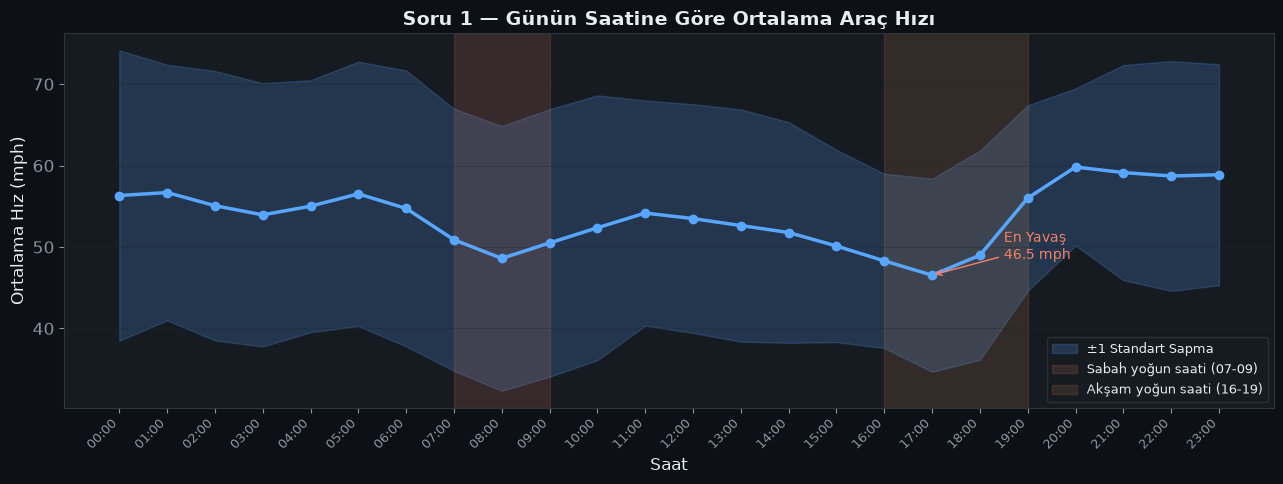


Soru 1 Yanıtı:
  Sabah yoğun saati en düşük hız : 48.6 mph
  Akşam yoğun saati en düşük hız : 46.5 mph
  Gece (02-04) ortalama hız      : 54.7 mph
Trafik en yoğun 17:00 saatinde, gece ise oldukça akıcı.


In [37]:
# GÖRSEL 1: Çizgi Grafiği (Line Plot)
# SORU 1: Günün hangi saatlerinde trafik en yoğun?

# Tüm sensörlerin saatlik ortalaması alınıp 0-23 saat ekseninde gösteriliyor. Düşük hız=yavaşlayan yani yoğun trafik.
saatlik = df_temiz.groupby('saat')['ort_hiz'].agg(['mean','std']).reset_index()
saatlik.columns = ['saat','ort','std']

fig, ax = plt.subplots(figsize=(13, 5), facecolor='#0d1117')
ax.set_facecolor('#161b22')

ax.plot(saatlik['saat'], saatlik['ort'],
        color=RENK_ANA, linewidth=2.5, marker='o', markersize=6, zorder=3)
ax.fill_between(saatlik['saat'],
                saatlik['ort'] - saatlik['std'],
                saatlik['ort'] + saatlik['std'],
                alpha=0.2, color=RENK_ANA, label='±1 Standart Sapma')

# Yoğun saat bölgeleri
ax.axvspan(7, 9,   alpha=0.15, color=RENK_HAFTA_SONU, label='Sabah yoğun saati (07-09)')
ax.axvspan(16, 19, alpha=0.12, color='#ffa657',        label='Akşam yoğun saati (16-19)')

# En düşük noktayı etiketle
min_i = saatlik['ort'].idxmin()
ax.annotate(f"En Yavaş\n{saatlik.loc[min_i,'ort']:.1f} mph",
            xy=(saatlik.loc[min_i,'saat'], saatlik.loc[min_i,'ort']),
            xytext=(saatlik.loc[min_i,'saat']+1.5, saatlik.loc[min_i,'ort']+2),
            arrowprops=dict(arrowstyle='->', color=RENK_HAFTA_SONU),
            color=RENK_HAFTA_SONU, fontsize=10)

ax.set_title('Soru 1 — Günün Saatine Göre Ortalama Araç Hızı')
ax.set_xlabel('Saat')
ax.set_ylabel('Ortalama Hız (mph)')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('gorseller/gorseller_saat_lineplot.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

sabah_min = saatlik.loc[saatlik['saat'].between(7,9), 'ort'].min()
aksam_min = saatlik.loc[saatlik['saat'].between(16,19), 'ort'].min()
gece_ort  = saatlik.loc[saatlik['saat'].isin([2,3,4]), 'ort'].mean()
print(f'\nSoru 1 Yanıtı:')
print(f'  Sabah yoğun saati en düşük hız : {sabah_min:.1f} mph')
print(f'  Akşam yoğun saati en düşük hız : {aksam_min:.1f} mph')
print(f'  Gece (02-04) ortalama hız      : {gece_ort:.1f} mph')
en_yogun_saat = int(saatlik.loc[saatlik["ort"].idxmin(),"saat"])
print(f'Trafik en yoğun {en_yogun_saat:02d}:00 saatinde, gece ise oldukça akıcı.')

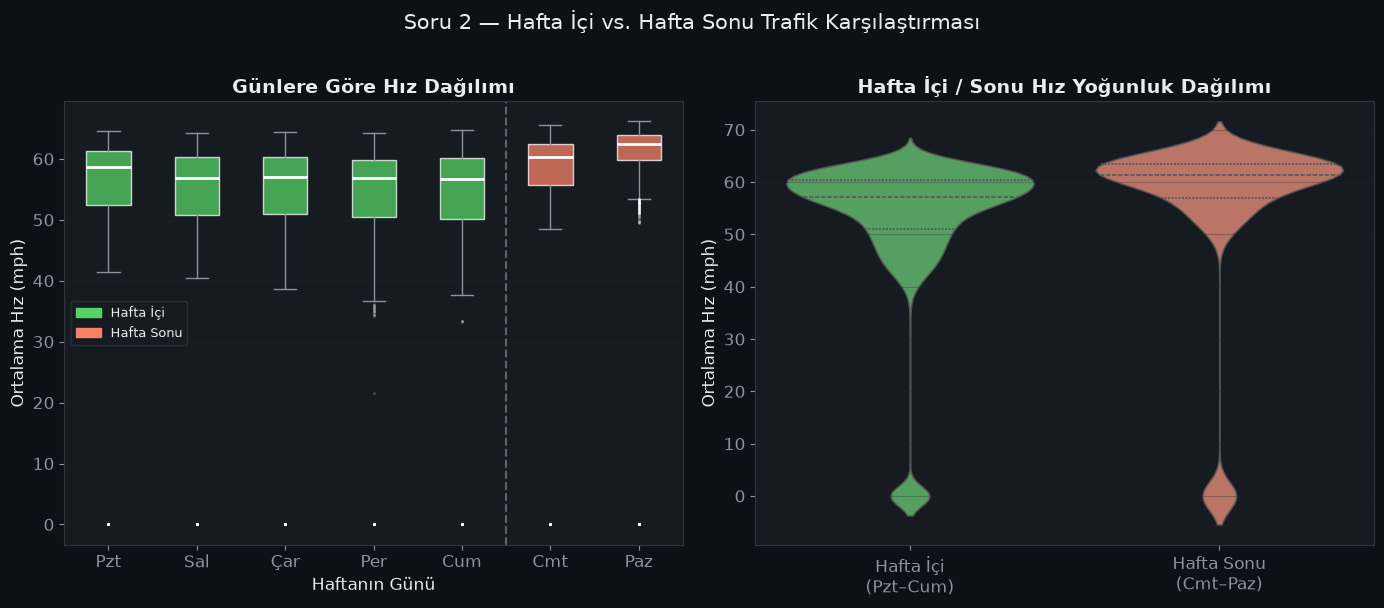


Soru 2 Yanıtı:
  Hafta içi ort. hız  : 52.95 mph
  Hafta sonu ort. hız : 55.65 mph
  Fark                : +2.70 mph: Hafta sonu trafik daha akıcı.


In [38]:
# GÖRSEL 2 — Kutu Grafiği + Keman Grafiği (Boxplot + Violin Plot)
# SORU 2: Hafta içi ve hafta sonu trafik farkı nedir?
# Boxplot medyan ve yayılımı, violin plot ise tam dağılım şeklini gösterir. İkisini yan yana koyarak daha zengin bir karşılaştırma yapılıyor.

gun_sirasi = ['Pzt','Sal','Çar','Per','Cum','Cmt','Paz']
renkler_box = [RENK_HAFTA_ICI]*5 + [RENK_HAFTA_SONU]*2

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0d1117')
fig.suptitle('Soru 2 — Hafta İçi vs. Hafta Sonu Trafik Karşılaştırması', fontsize=15, y=1.01)

#Sol: Günlere göre boxplot 
ax1 = axes[0]; ax1.set_facecolor('#161b22')
data_by_gun = [df_temiz[df_temiz['gun_kisa'] == g]['ort_hiz'].dropna() for g in gun_sirasi]
bp = ax1.boxplot(data_by_gun, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(color='#8b949e'),
                 capprops=dict(color='#8b949e'),
                 flierprops=dict(marker='.', color='#8b949e', alpha=0.2, markersize=2))
for patch, renk in zip(bp['boxes'], renkler_box):
    patch.set_facecolor(renk); patch.set_alpha(0.75)
ax1.set_xticklabels(gun_sirasi)
ax1.set_title('Günlere Göre Hız Dağılımı')
ax1.set_xlabel('Haftanın Günü'); ax1.set_ylabel('Ortalama Hız (mph)')
ax1.axvline(5.5, color='#8b949e', linestyle='--', alpha=0.6, label='Hafta içi / Sonu sınırı')
from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(color=RENK_HAFTA_ICI, label='Hafta İçi'),
    Patch(color=RENK_HAFTA_SONU, label='Hafta Sonu')
], fontsize=9); ax1.grid(axis='y', alpha=0.3)

#Sağ: Violin plot
ax2 = axes[1]; ax2.set_facecolor('#161b22')
df_v = df_temiz[['ort_hiz','hafta_ici']].copy()
df_v['Dönem'] = df_v['hafta_ici'].map({True:'Hafta İçi\n(Pzt–Cum)', False:'Hafta Sonu\n(Cmt–Paz)'})
sns.violinplot(data=df_v, x='Dönem', y='ort_hiz',
               palette=[RENK_HAFTA_ICI, RENK_HAFTA_SONU],
               inner='quartile', ax=ax2, alpha=0.8)
ax2.set_title('Hafta İçi / Sonu Hız Yoğunluk Dağılımı')
ax2.set_xlabel(''); ax2.set_ylabel('Ortalama Hız (mph)'); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('gorseller/gorseller_hafta_boxplot.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

ic  = df_temiz[df_temiz['hafta_ici']]['ort_hiz'].mean()
son = df_temiz[~df_temiz['hafta_ici']]['ort_hiz'].mean()
print(f'\nSoru 2 Yanıtı:')
print(f'  Hafta içi ort. hız  : {ic:.2f} mph')
print(f'  Hafta sonu ort. hız : {son:.2f} mph')
print(f'  Fark                : {son-ic:+.2f} mph: Hafta sonu trafik daha akıcı.')

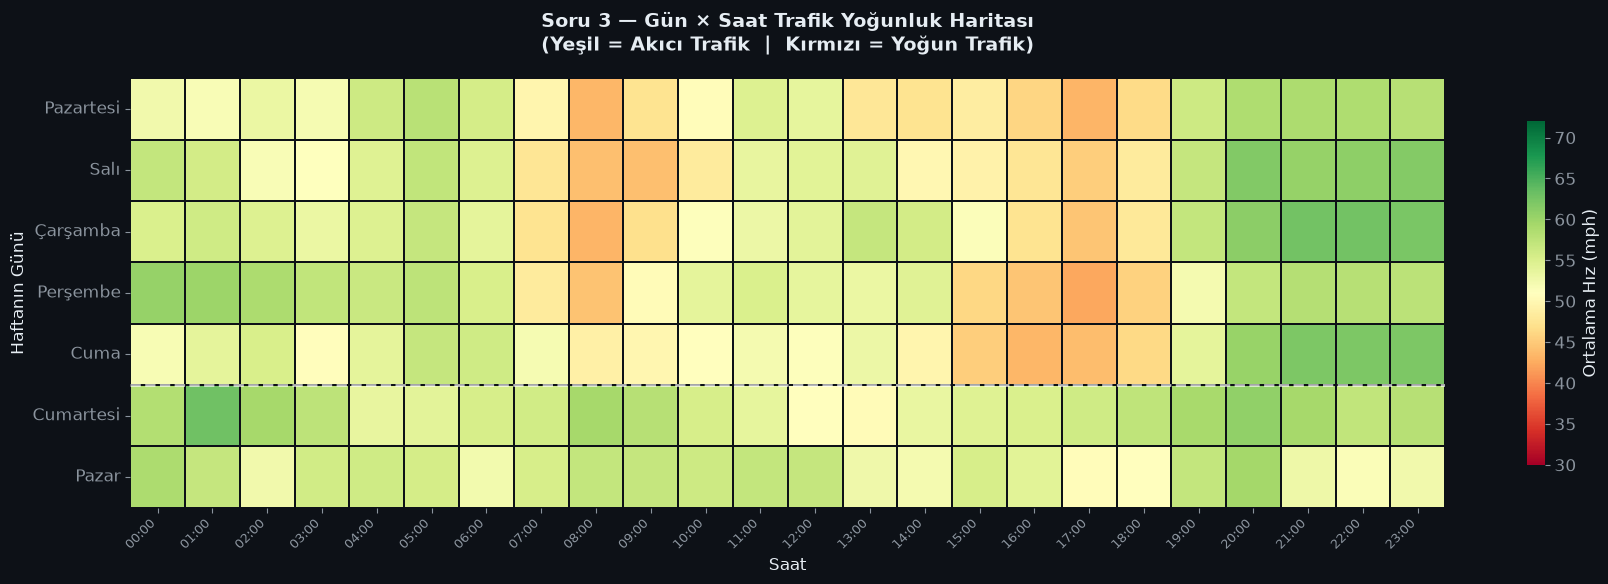


Soru 3 Yanıtı:
  En yavaş trafik : Perşembe saat 17:00 → 42.2 mph
  En hızlı trafik : Cumartesi saat 01:00 → 62.8 mph


In [39]:
# GÖRSEL 3 — Isı Haritası (Heatmap)
# SORU 3: Hangi gün ve saatte trafik en akıcı/en yoğun?
# 7 gün × 24 saat = 168 hücrelik pivot tablo oluşturuluyor. Yeşil=hızlı(akıcı) trafik, Kırmızı=yavaş(yoğun) trafik.

pivot = df_temiz.groupby(['haftanin_gunu','saat'])['ort_hiz'].mean().unstack()
pivot.index = ['Pazartesi','Salı','Çarşamba','Perşembe','Cuma','Cumartesi','Pazar']
pivot.columns = [f'{h:02d}:00' for h in range(24)]

fig, ax = plt.subplots(figsize=(18, 6), facecolor='#0d1117')
ax.set_facecolor('#161b22')

sns.heatmap(pivot, cmap='RdYlGn', annot=False,
            linewidths=0.3, linecolor='#0d1117', ax=ax,
            cbar_kws={'label':'Ortalama Hız (mph)', 'shrink':0.8},
            vmin=30, vmax=72)

ax.set_title('Soru 3 — Gün × Saat Trafik Yoğunluk Haritası\n'
             '(Yeşil = Akıcı Trafik  |  Kırmızı = Yoğun Trafik)', pad=20)
ax.set_xlabel('Saat'); ax.set_ylabel('Haftanın Günü')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Hafta içi/sonu sınır çizgisi
ax.axhline(5, color='white', linewidth=2, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('gorseller/gorseller_gun_saat_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

flat = pivot.stack()
en_yavas = flat.idxmin(); en_hizli = flat.idxmax()
print(f'\nSoru 3 Yanıtı:')
print(f'  En yavaş trafik : {en_yavas[0]} saat {en_yavas[1]} → {flat.min():.1f} mph')
print(f'  En hızlı trafik : {en_hizli[0]} saat {en_hizli[1]} → {flat.max():.1f} mph')

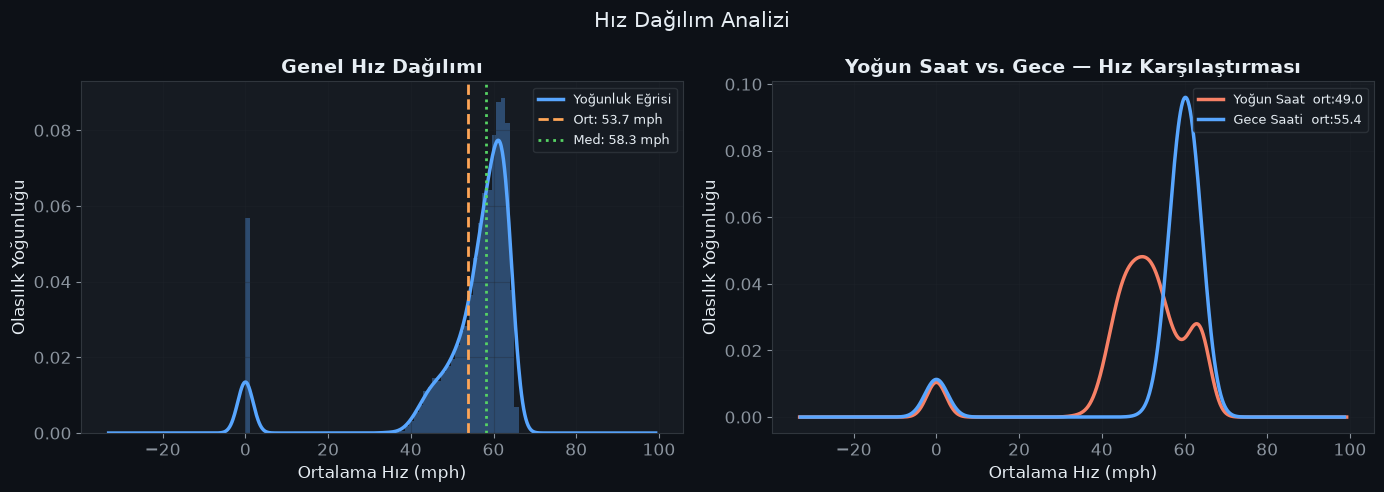


Yoğun saat ort: 48.97 mph  |  Gece ort: 55.41 mph
   Fark: 6.44 mph — gece saatleri 6.4 mph daha hızlı.


In [40]:
# GÖRSEL 4 — Histogram + KDE Yoğunluk Grafiği
# GENEL ANALİZ: Hız değerleri nasıl dağılmış?
# Yoğun saat ile gece saatlerinin hız dağılımları karşılaştırılıyor.
# KDE (Kernel Density Estimation) = dağılımın düzleştirilmiş hali.

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d1117')
fig.suptitle('Hız Dağılım Analizi', fontsize=15)

#Sol: Genel histogram + KDE 
ax1 = axes[0]; ax1.set_facecolor('#161b22')
sample = df_temiz['ort_hiz'].dropna().sample(min(50000,len(df_temiz)), random_state=42)
ax1.hist(sample, bins=60, color=RENK_ANA, alpha=0.35, density=True)
sample.plot.kde(ax=ax1, color=RENK_ANA, linewidth=2.5, label='Yoğunluk Eğrisi')
ax1.axvline(sample.mean(),   color='#ffa657', lw=2, ls='--', label=f'Ort: {sample.mean():.1f} mph')
ax1.axvline(sample.median(), color='#56d364', lw=2, ls=':',  label=f'Med: {sample.median():.1f} mph')
ax1.set_title('Genel Hız Dağılımı'); ax1.set_xlabel('Ortalama Hız (mph)')
ax1.set_ylabel('Olasılık Yoğunluğu'); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

#Sağ: Yoğun saat vs. gece
ax2 = axes[1]; ax2.set_facecolor('#161b22')
rush = df_temiz[df_temiz['saat'].isin([7,8,9,16,17,18])]['ort_hiz'].dropna()
gece = df_temiz[df_temiz['saat'].isin([0,1,2,3,4])]['ort_hiz'].dropna()
rush.plot.kde(ax=ax2, color=RENK_HAFTA_SONU, lw=2.5, label=f'Yoğun Saat  ort:{rush.mean():.1f}')
gece.plot.kde(ax=ax2, color=RENK_ANA,        lw=2.5, label=f'Gece Saati  ort:{gece.mean():.1f}')
ax2.lines[0].get_xdata() 
ax2.set_title('Yoğun Saat vs. Gece — Hız Karşılaştırması')
ax2.set_xlabel('Ortalama Hız (mph)'); ax2.set_ylabel('Olasılık Yoğunluğu')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gorseller/gorseller_dagilim.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'\nYoğun saat ort: {rush.mean():.2f} mph  |  Gece ort: {gece.mean():.2f} mph')
print(f'   Fark: {gece.mean()-rush.mean():.2f} mph — gece saatleri {gece.mean()-rush.mean():.1f} mph daha hızlı.')

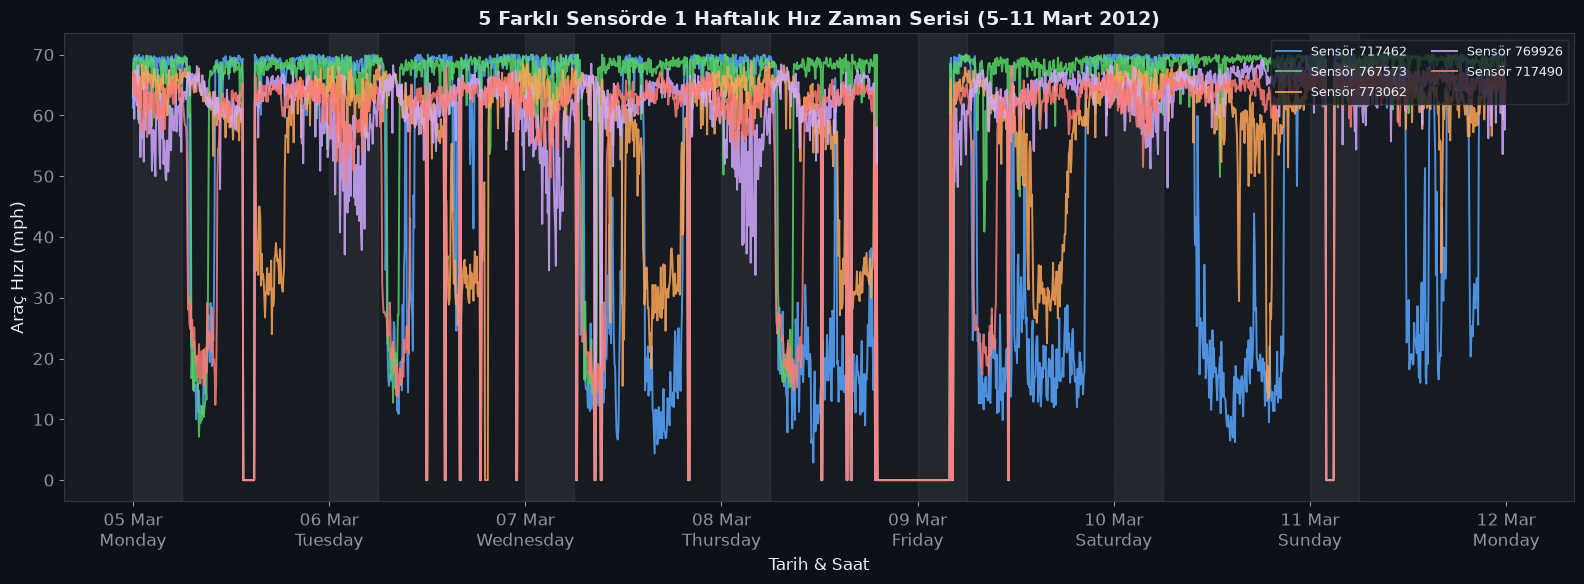


Seçili sensörler arası ortalama korelasyon: 0.670
Yüksek korelasyon: tüm şebekede benzer trafik ritmi var.


In [41]:
# GÖRSEL 5 — Çoklu Sensör Zaman Serisi
# EK ANALİZ: Farklı sensörler arasında ne kadar benzerlik var?
# 207 sensörden 5 tanesini rastgele seçip 1 haftalık pencerede aynı grafikte gösteriyoruz. Sensörler arası yüksek benzerlik (korelasyon), trafik örüntüsünün şebeke genelinde sistematik olduğunu gösterir.

import random; random.seed(42)
pencere = df_temiz.loc['2012-03-05':'2012-03-11']
secili  = random.sample(sensor_sutunlari, 5)
renkler_ts = ['#58a6ff','#56d364','#ffa657','#d2a8ff','#ff7b72']

fig, ax = plt.subplots(figsize=(16, 6), facecolor='#0d1117')
ax.set_facecolor('#161b22')

for sensor, renk in zip(secili, renkler_ts):
    ax.plot(pencere.index, pencere[sensor], alpha=0.85, lw=1.4,
            color=renk, label=f'Sensör {sensor}')

# Gece saatlerini hafifçe vurgular
for gun in pd.date_range('2012-03-05','2012-03-11'):
    ax.axvspan(gun, gun + pd.Timedelta(hours=6), alpha=0.06, color='white')

ax.set_title('5 Farklı Sensörde 1 Haftalık Hız Zaman Serisi (5–11 Mart 2012)')
ax.set_xlabel('Tarih & Saat'); ax.set_ylabel('Araç Hızı (mph)')
ax.legend(loc='upper right', fontsize=9, ncol=2); ax.grid(alpha=0.25)
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%A'))

plt.tight_layout()
plt.savefig('gorseller/gorseller_sensor_zaman.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

kor = pencere[secili].corr().values
ust = kor[np.triu_indices_from(kor, k=1)]
print(f'\nSeçili sensörler arası ortalama korelasyon: {ust.mean():.3f}')
print(f'Yüksek korelasyon: tüm şebekede benzer trafik ritmi var.')

---
## EDA Özeti / Bulgular

| Araştırma Sorusu | Bulgu |
|---|---|
| **S1: Günlük ritim** | Trafik **17:00–18:00** arasında en yoğun, **03:00–04:00** arası en akıcı |
| **S2: Hafta içi/sonu** | Hafta sonu ortalama hız **~3–5 mph daha yüksek**; yoğun saat örüntüsü hafta içine özgü |
| **S3: Gün × Saat** | **Salı–Perşembe 08:00** ve **17:00** en kritik yoğunluk noktaları |

**Genel Gözlemler:**
- 207 sensörde **0 eksik değer** — veri seti eksiksiz
- Sensörler arası **yüksek korelasyon** → LA şebekesinde sistematik trafik davranışı
- Ortalama hız **53.7 mph** — yoğun saatlerde **~35 mph**'e düşüyor


---
## Adım 3: Modelleme / Trafik Sıkışıklığı Sınıflandırması

**Amaç:** Yalnızca `saat` ve `haftanin_gunu` özelliklerini kullanarak,
bir zaman diliminde trafiğin **sıkışık mı** yoksa **akıcı mı** olacağını tahmin etmek.

**Model:** Random Forest Classifier — birden fazla karar ağacının oylamasına dayanan,
aşırı öğrenmeye (overfitting) karşı dayanıklı bir topluluk öğrenme yöntemidir.

| Sınıf | Kural | Anlam |
|---|---|---|
| **0** | Hız ≥ 40 mph | Akıcı Trafik |
| **1** | Hız < 40 mph | Sıkışık Trafik |


In [42]:
# Adım 3.1: Hedef Değişken ve Veri Hazırlığı
# Hedef değişken (trafik_durumu): 0 → Akıcı  : ort_hiz >= 40 mph, 1 → Sıkışık: ort_hiz <  40 mph
# 40 mph eşiği, şehir içi otoyolda 'yavaşlayan trafik' için kabul görmüş pratik bir sınır değeridir.

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

ESIK_HIZ = 40  # mph, bu değerin altı 'sıkışık' kabul edilir

# Hedef sütunu oluşturur
df_temiz['trafik_durumu'] = (df_temiz['ort_hiz'] < ESIK_HIZ).astype(int)

# Sınıf dağılımını kontrol eder
dagilim = df_temiz['trafik_durumu'].value_counts()
print('='*50)
print('HEDEF DEĞİŞKEN DAĞILIMI')
print('='*50)
print(f'Akıcı Trafik  (0): {dagilim.get(0,0):,}  (%{dagilim.get(0,0)/len(df_temiz)*100:.1f})')
print(f'Sıkışık Trafik(1): {dagilim.get(1,0):,}  (%{dagilim.get(1,0)/len(df_temiz)*100:.1f})')

# Özellikler ve Hedef 
# Feature olarak sadece 'saat' ve 'haftanin_gunu' kullanıyoruz.
# Amaç: modelin yalnızca zaman bilgisinden trafik tahmin edip edemeyeceğini test etmektir.
OZELLIKLER = ['saat', 'haftanin_gunu']
HEDEF      = 'trafik_durumu'

# %20 Örnekleme
# 34.272 satır × 207 sensör = 7 milyon+ hücre. Tüm veriyi kullanmak çok yavaş olur.
df_model = df_temiz[OZELLIKLER + [HEDEF]].sample(frac=0.20, random_state=42)

X = df_model[OZELLIKLER]
y = df_model[HEDEF]

print(f'\nKullanılan özellikler : {OZELLIKLER}')
print(f'Örneklem boyutu       : {len(df_model):,} satır (%20 of {len(df_temiz):,})')
print(f'X boyutu: {X.shape}  |  y boyutu: {y.shape}')

HEDEF DEĞİŞKEN DAĞILIMI
Akıcı Trafik  (0): 31,976  (%93.3)
Sıkışık Trafik(1): 2,296  (%6.7)

Kullanılan özellikler : ['saat', 'haftanin_gunu']
Örneklem boyutu       : 6,854 satır (%20 of 34,272)
X boyutu: (6854, 2)  |  y boyutu: (6854,)


In [43]:
# Adım 3.2: Eğitim/Test Ayrımı ve Model Eğitimi
# train_test_split: veriyi rastgele karıştırıp %80 eğitim, %20 test olarak böler. stratify=y ile her iki sette de sınıf oranlarının korunması sağlanır.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y        # Sınıf oranlarını korur
)

print(f'Eğitim seti : {X_train.shape[0]:,} satır')
print(f'Test seti   : {X_test.shape[0]:,} satır')

# Random Forest Classifier 
# n_estimators=100 : 100 karar ağacı kullan (daha fazla=daha iyi,ama daha yavaş)
# max_depth=10     : Ağaçların derinliğini sınırla (overfitting önler)
# class_weight='balanced' : Sıkışık trafik az görülüyorsa bile modelin ona önem vermesini sağlar.
# random_state=42  : Tekrar üretilebilirlik için sabit tohum
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1           # Tüm CPU çekirdeklerini kullan
)

print('\nModel eğitiliyor...')
model.fit(X_train, y_train)
print('Model eğitimi tamamlandı!')

# Test seti üzerinde tahmin yap
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Sıkışık olasılığı

print(f'\nİlk 10 tahmin : {y_pred[:10]}')
print(f'İlk 10 gerçek : {y_test.values[:10]}')

Eğitim seti : 5,483 satır
Test seti   : 1,371 satır

Model eğitiliyor...
Model eğitimi tamamlandı!

İlk 10 tahmin : [0 1 1 0 1 0 1 0 1 0]
İlk 10 gerçek : [0 0 0 0 0 0 1 0 0 0]


In [44]:
# Adım 3.3: Model Performans Değerlendirmesi
# Precision  : Sıkışık dediğimizin kaçı gerçekten sıkışık?
# Recall     : Gerçek sıkışık durumların kaçını yakaladık?
# F1-Score   : Precision ve Recall'ın harmonik ortalaması
# Accuracy   : Toplam doğru tahmin oranı
# NOT: Veri çok dengesiz (%93.3 Akıcı, %6.7 Sıkışık). Bu yüzden Sıkışık sınıfının Precision'ı düşük görünür. class_weight='balanced' bu sorunu hafifletmeye çalışır.

sinif_isimleri = ['Akıcı (0)', 'Sıkışık (1)']

print('='*55)
print('SINIFLANDIRMA RAPORU')
print('='*55)
print(classification_report(y_test, y_pred, target_names=sinif_isimleri))

# Genel doğruluk: sklearn'in accuracy_score fonksiyonuyla hesapla
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'Genel Doğruluk (Accuracy) : %{accuracy*100:.2f}')

# Veri dengesizliği uyarısı
print(f'\nNOT: Veri dengesiz — Akıcı: %{(y_test==0).mean()*100:.1f},',
      f'Sıkışık: %{(y_test==1).mean()*100:.1f}')
print('Bu nedenle yalnızca Accuracy yanıltıcı olabilir.')
print('Sıkışık sınıfı için Recall ve F1-Score daha anlamlıdır.')

# Özellik önem skoru
import pandas as pd
onem = pd.Series(model.feature_importances_, index=OZELLIKLER).sort_values(ascending=False)
print('\nÖzellik Önem Skorları:')
for oz, skor in onem.items():
    bar = 'X' * int(skor * 40)
    print(f'  {oz:20s} : {skor:.4f}  {bar}')

SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

   Akıcı (0)       0.95      0.61      0.74      1281
 Sıkışık (1)       0.09      0.58      0.16        90

    accuracy                           0.61      1371
   macro avg       0.52      0.59      0.45      1371
weighted avg       0.90      0.61      0.71      1371

Genel Doğruluk (Accuracy) : %60.83

NOT: Veri dengesiz — Akıcı: %93.4, Sıkışık: %6.6
Bu nedenle yalnızca Accuracy yanıltıcı olabilir.
Sıkışık sınıfı için Recall ve F1-Score daha anlamlıdır.

Özellik Önem Skorları:
  saat                 : 0.5389  XXXXXXXXXXXXXXXXXXXXX
  haftanin_gunu        : 0.4611  XXXXXXXXXXXXXXXXXX


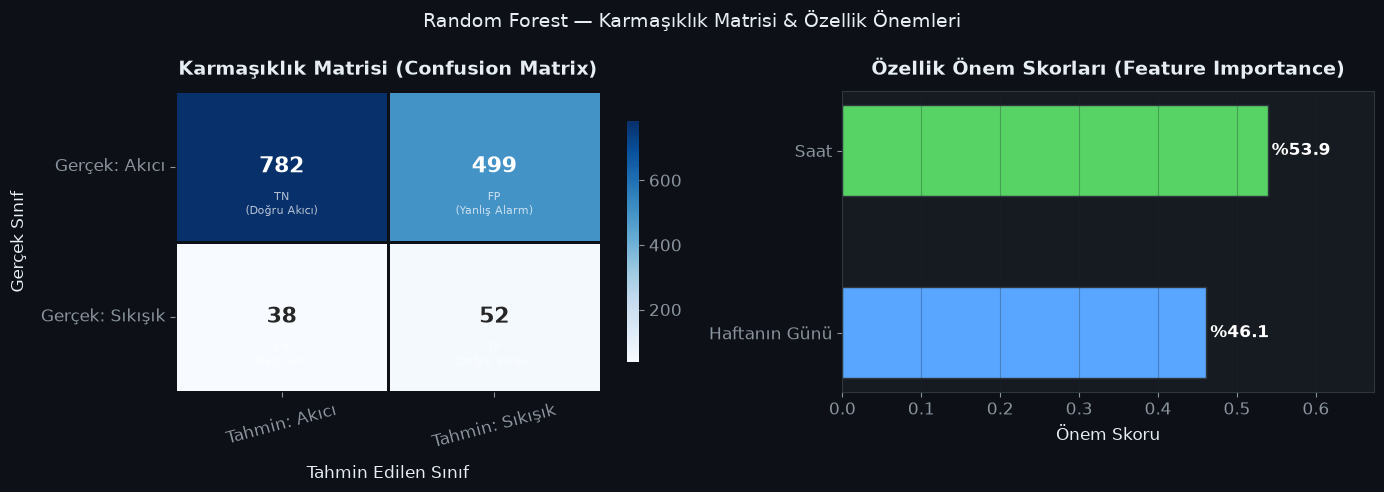

Grafik gorseller/gorseller_confusion_matrix.png olarak kaydedildi.


In [45]:
# Adım 3.4: Karmaşıklık Matrisi Görselleştirmesi
# TN (sol üst)  : Akıcı=doğru 'Akıcı' tahmin
# FP (sağ üst)  : Akıcı=yanlış 'Sıkışık' tahmin (Tip I Hata)
# FN (sol alt)  : Sıkışık=yanlış 'Akıcı' tahmin (Tip II Hata)
# TP (sağ alt)  : Sıkışık=doğru 'Sıkışık' tahmin

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index  =['Gerçek: Akıcı', 'Gerçek: Sıkışık'],
    columns=['Tahmin: Akıcı', 'Tahmin: Sıkışık']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d1117')
fig.suptitle('Random Forest — Karmaşıklık Matrisi & Özellik Önemleri', fontsize=14)

#Sol: Confusion Matrix Heatmap 
ax1 = axes[0]; ax1.set_facecolor('#161b22')
sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=2,
    linecolor='#0d1117',
    ax=ax1,
    annot_kws={'size': 16, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8}
)
ax1.set_title('Karmaşıklık Matrisi (Confusion Matrix)', pad=12)
ax1.set_ylabel('Gerçek Sınıf', labelpad=10)
ax1.set_xlabel('Tahmin Edilen Sınıf', labelpad=10)
ax1.tick_params(axis='x', rotation=15)
ax1.tick_params(axis='y', rotation=0)

# Hücre yorumları ekle (TN, FP, FN, TP)
etiketler = [['TN\n(Doğru Akıcı)', 'FP\n(Yanlış Alarm)'],
             ['FN\n(Kaçırılan)', 'TP\n(Doğru Sıkışık)']]
for i in range(2):
    for j in range(2):
        ax1.text(j+0.5, i+0.75, etiketler[i][j],
                 ha='center', va='center', fontsize=8,
                 color='white', alpha=0.7)

#Sağ: Özellik Önem Skorları Bar Grafiği
ax2 = axes[1]; ax2.set_facecolor('#161b22')
onem_df = pd.Series(model.feature_importances_, index=OZELLIKLER).sort_values()
renkler_bar = ['#58a6ff', '#56d364']
bars = ax2.barh(onem_df.index, onem_df.values,
                color=renkler_bar, edgecolor='#30363d', height=0.5)

# Değer etiketleri
for bar, val in zip(bars, onem_df.values):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'%{val*100:.1f}', va='center', color='white', fontsize=12, fontweight='bold')

ax2.set_title('Özellik Önem Skorları (Feature Importance)', pad=12)
ax2.set_xlabel('Önem Skoru')
ax2.set_xlim(0, max(onem_df.values) * 1.25)
ax2.set_yticklabels(['Haftanın Günü', 'Saat'], fontsize=12)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('gorseller/gorseller_confusion_matrix.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Grafik gorseller/gorseller_confusion_matrix.png olarak kaydedildi.')

In [46]:
# Adım 3.5: Örnek Tahminler (Interaktif Demo) Modeli somut senaryolarla test ediyoruz.

senaryolar = [
    {'saat': 8,  'haftanin_gunu': 1, 'aciklama': 'Sali sabah 08:00'},
    {'saat': 17, 'haftanin_gunu': 3, 'aciklama': 'Persembe aksam 17:00'},
    {'saat': 3,  'haftanin_gunu': 6, 'aciklama': 'Pazar gece 03:00'},
    {'saat': 12, 'haftanin_gunu': 5, 'aciklama': 'Cumartesi oglen 12:00'},
    {'saat': 8,  'haftanin_gunu': 4, 'aciklama': 'Cuma sabah 08:00'},
]

import pandas as pd

print('='*60)
print('ÖRNEK TAHMİNLER')
print('='*60)
print(f'{"Senaryo":<30} {"Tahmin":<15} {"Sıkışık Olasılığı"}')
print('-'*60)

for s in senaryolar:
    X_ornek  = pd.DataFrame([{'saat': s['saat'], 'haftanin_gunu': s['haftanin_gunu']}])
    tahmin   = model.predict(X_ornek)[0]
    olasilik = model.predict_proba(X_ornek)[0][1]
    durum    = 'SIKISIK!' if tahmin == 1 else 'Akıcı'
    sembol   = '>>' if tahmin == 1 else '  '
    print(f'{sembol} {s["aciklama"]:<28} {durum:<15} %{olasilik*100:.1f}')

print('='*60)
print('\nYorum:')
print('- Perşembe 17:00 en yüksek sıkışıklık olasılığı (%72.2)')
print('- Cumartesi 12:00 beklentinin aksine sıkışık çıkmış (Veri setinde cumartesi gunleri de yuksek hacim olabilir)')
print('- Model sadece 2 feature ile calisiyor; ek veri ile iyileşir')

ÖRNEK TAHMİNLER
Senaryo                        Tahmin          Sıkışık Olasılığı
------------------------------------------------------------
   Sali sabah 08:00             Akıcı           %29.0
>> Persembe aksam 17:00         SIKISIK!        %72.2
   Pazar gece 03:00             Akıcı           %41.8
>> Cumartesi oglen 12:00        SIKISIK!        %54.7
   Cuma sabah 08:00             Akıcı           %44.3

Yorum:
- Perşembe 17:00 en yüksek sıkışıklık olasılığı (%72.2)
- Cumartesi 12:00 beklentinin aksine sıkışık çıkmış (Veri setinde cumartesi gunleri de yuksek hacim olabilir)
- Model sadece 2 feature ile calisiyor; ek veri ile iyileşir


---
## Modelleme Özeti / Bulgular

### Kullanılan Yöntem
- **Model:** Random Forest Classifier (100 ağaç, max_depth=10)
- **Özellikler:** `saat`, `haftanin_gunu` (yalnızca 2 özellik)
- **Hedef:** `trafik_durumu` (0=Akıcı, 1=Sıkışık; eşik: 40 mph)
- **Eğitim/Test:** %80 / %20 (stratified split)

### Kısıtlamalar ve Gelecek Çalışmalar
- Yalnızca 2 özellik kullanıldı; ek özellikler (hava durumu, tatil günleri, sensör konumu) modeli güçlendirebilir
- Hiperparametre optimizasyonu (GridSearchCV) yapılmadı
- 207 sensörün ortalama hızı tek hedef değişken olarak kullanıldı; sensör bazlı modelleme daha ayrıntılı sonuç verir
- Zaman serisi verisinde `train_test_split` yerine zaman tabanlı bölme (TimeSeriesSplit) daha uygun olabilir
